In [14]:
import pandas as pd

from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

# Functions


In [15]:
def working_df(data, gw, features=None, joint=False):
    # # Split
    # GW_TRAIN_END = gw - 1
    # train_mask = GW_full <= GW_TRAIN_END
    # test_mask = GW_full == (GW_TRAIN_END + 1)

    GW_TRAIN_END = gw - 1

    GW_full = data['round'].values
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['name'].values
    test_player_ids = test_data['element'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['name', 'element', 'team', 'round'])
    train_data = train_data.drop(columns=['name', 'element', 'team', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'name': full_data[test_mask]['name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Feature Engineering


In [39]:
player_data = pd.read_csv('./rolled_data_24_25.csv')

identifiers = [ 'element', 'name',  'position', 'round', 'fixture', 'team']

cols = [
    'value', 'selected', 'transfers_in', 'transfers_out', 'difficulty', 'opponent_difficulty', 'win_prob', 'draw_prob', 'lose_prob',
    'percentage_net_transfers', 'xP',  'selected_by_percent', 'ownership_change', 'was_home', 'team', 'opponent_team',

    'points_rolling_1', 'points_rolling_3', 'points_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'team_h_score_rolling_1',
    'team_a_score_rolling_1','minutes_rolling_1',
    'minutes_rolling_3', 'minutes_rolling_5', 'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'assists_rolling_1',
    'assists_rolling_3', 'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'goals_conceded_rolling_1',
    'goals_conceded_rolling_3', 'goals_conceded_rolling_5', 'own_goals_rolling_1', 'own_goals_rolling_3', 'own_goals_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'saves_rolling_1',
    'saves_rolling_3', 'saves_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'creativity_rolling_1', 'creativity_rolling_3',
    'creativity_rolling_5', 'threat_rolling_1', 'threat_rolling_3', 'threat_rolling_5', 'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5',
    'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5',
    'expected_assists_rolling_1', 'expected_assists_rolling_3', 'expected_assists_rolling_5', 'expected_goal_involvements_rolling_1',
    'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'expected_goals_conceded_rolling_1', 'expected_goals_conceded_rolling_3',
    'expected_goals_conceded_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5', 'selected_rolling_1', 'selected_rolling_3',
    'selected_rolling_5', 'interceptions_rolling_1', 'interceptions_rolling_3', 'interceptions_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'blocks_rolling_1', 'blocks_rolling_3', 'blocks_rolling_5', 'clearances_rolling_1', 'clearances_rolling_3',
    'clearances_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'total_shots_rolling_1', 'total_shots_rolling_3',
    'total_shots_rolling_5', 'chances_created_rolling_1', 'chances_created_rolling_3', 'chances_created_rolling_5', 'goals_prevented_rolling_1',
    'goals_prevented_rolling_3', 'goals_prevented_rolling_5', 'sweeper_actions_rolling_1', 'sweeper_actions_rolling_3', 'sweeper_actions_rolling_5',
    'tackles_won_percent_rolling_1', 'tackles_won_percent_rolling_3', 'tackles_won_percent_rolling_5',

    'points_1_ewm', 'points_3_ewm', 'points_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm',
    'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm',
    'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm',
    'saves_1_ewm', 'saves_3_ewm',
    'saves_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'threat_1_ewm',
    'threat_3_ewm', 'threat_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm', 'starts_1_ewm', 'starts_3_ewm', 'starts_5_ewm',
    'expected_goals_1_ewm', 'expected_goals_3_ewm', 'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm',
    'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'expected_goals_conceded_1_ewm',
    'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'selected_1_ewm', 'selected_3_ewm',
    'selected_5_ewm', 'interceptions_1_ewm', 'interceptions_3_ewm', 'interceptions_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm',
    'blocks_1_ewm', 'blocks_3_ewm', 'blocks_5_ewm', 'clearances_1_ewm', 'clearances_3_ewm', 'clearances_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm',
    'tackles_5_ewm', 'total_shots_1_ewm', 'total_shots_3_ewm', 'total_shots_5_ewm', 'chances_created_1_ewm', 'chances_created_3_ewm', 'chances_created_5_ewm',
    'goals_prevented_1_ewm', 'goals_prevented_3_ewm', 'goals_prevented_5_ewm', 'sweeper_actions_1_ewm', 'sweeper_actions_3_ewm', 'sweeper_actions_5_ewm',
    'tackles_won_percent_1_ewm', 'tackles_won_percent_3_ewm', 'tackles_won_percent_5_ewm'
]

hist_data = player_data[
    (player_data['round'] < 9)  &
    # (player_data['minutes_rolling_3'] > 15) &
    (player_data['minutes'] > 15)
    ]

hist_data[cols]

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,draw_prob,lose_prob,percentage_net_transfers,...,chances_created_5_ewm,goals_prevented_1_ewm,goals_prevented_3_ewm,goals_prevented_5_ewm,sweeper_actions_1_ewm,sweeper_actions_3_ewm,sweeper_actions_5_ewm,tackles_won_percent_1_ewm,tackles_won_percent_3_ewm,tackles_won_percent_5_ewm
43,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,0.106,0.056,-0.000263,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.625,24.279835
74,60.0,1167503.0,0.0,0.0,3.0,5.0,0.801,0.126,0.073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,60.0,1248259.0,36723.0,61907.0,4.0,5.0,0.536,0.247,0.217,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000
76,60.0,1296327.0,86679.0,85826.0,3.0,5.0,0.715,0.173,0.112,-0.004402,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000
77,60.0,1208425.0,61041.0,176466.0,3.0,5.0,0.413,0.271,0.316,-0.028007,...,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,100.0,50.000,33.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24436,50.0,1665.0,331.0,275.0,2.0,2.0,0.529,0.251,0.220,0.000014,...,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,100.0,62.500,48.148148
24437,50.0,1722.0,149.0,233.0,3.0,2.0,0.180,0.189,0.631,0.000003,...,0.222222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.250,32.098765
24470,55.0,996.0,89.0,181.0,5.0,3.0,0.119,0.166,0.716,0.000011,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.000,22.222222
24471,55.0,1382.0,318.0,165.0,3.0,3.0,0.278,0.262,0.460,0.000036,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.500,14.814815


In [ ]:
categorical_cols = ['team', 'opponent_team', 'was_home']

hist_data = player_data[
    (player_data['round'] < 9) &
    (player_data['minutes'] > 15)
].copy()

# Fill numerical missing values
hist_data = hist_data.fillna(0)

# Convert categorical variables
for col in categorical_cols:
    hist_data[col] = hist_data[col].astype('category')
hist_data['team'].dtype

CategoricalDtype(categories=['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford',
                  'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham',
                  'Ipswich', 'Leicester', 'Liverpool', 'Man City', 'Man Utd',
                  'Newcastle', 'Nott'm Forest', 'Southampton', 'Spurs',
                  'West Ham', 'Wolves'],
, ordered=False, categories_dtype=object)

In [69]:
# Check for non-numeric columns in your feature set
non_numeric_in_cols = hist_data[cols].select_dtypes(include=['object', 'category']).columns.tolist()

print("All non-numeric columns in cols:", non_numeric_in_cols)

# Find columns PyCaret thinks are numeric because they aren't in categorical_cols
untracked_categoricals = [c for c in non_numeric_in_cols if c not in categorical_cols]
print("Rogue columns causing the crash:", untracked_categoricals)

All non-numeric columns in cols: ['was_home', 'team', 'opponent_team']
Rogue columns causing the crash: []


In [ ]:
from pycaret.regression import (
    setup,
    compare_models,
    tune_model,
    plot_model,
    finalize_model,
    predict_model,
    save_model
)

hist_data = player_data[
    (player_data['round'] < 9)  &
    (player_data['minutes'] > 15)
    ].fillna(0)

metadata_to_exclude# 3. PRE-ENCODE STRINGS TO INTEGER CODES (Bypasses PyCaret string math bug)
hist_data['team_code'] = hist_data['team'].astype('category').cat.codes
hist_data['opponent_team_code'] = hist_data['opponent_team'].astype('category').cat.codes
hist_data['was_home'] = hist_data['was_home'].astype(int)

# Optional: Store team mapping dictionary for reference later
team_mapping = dict(enumerate(hist_data['team'].astype('category').cat.categories))

# 4. Build clean feature list
categorical_cols = ['team_code', 'opponent_team_code', 'was_home']

clean_cols = cols #[c for c in cols if c not in cols and c not in ['team', 'opponent_team']]
clean_cols.extend(['team_code', 'opponent_team_code'])
clean_cols = list(dict.fromkeys(clean_cols))  # Preserve order & remove duplicates

# Initialize PyCaret Regression
xp_model = setup(
    data=hist_data[cols],
    target='xP',       # Target: Next Gameweek points
    session_id=42,

    # Declare categorical featurest'].dtyp
    categorical_features=categorical_cols,
    max_encoding_ohe=25,             # Ensures all 20 teams get One-Hot Encoded

    # Feature Cleanup & Reduction
    low_variance_threshold=0.01,     # Drop constant / static features
    remove_multicollinearity=True,   # Drop collinear features (e.g., overlapping rolling xG)
    multicollinearity_threshold=0.85,

    # Automated Feature Selection
    feature_selection=True,
    feature_selection_method='classic',
    n_features_to_select=0.25,       # Keep top 25% features (or pass an int like 25)

    # Train / Test Split
    train_size=0.8,
    fold=5,                          # 5-fold cross-validation

    # Ignore IDs & non-predictive metadata from modeling
    # ignore_features=['player_id', 'player_name', 'gameweek']
)

ValueError: could not convert string to float: 'Newcastle'

# PYCARET


## GW 1-8


In [17]:
hist_data = player_data[
    (player_data['round'] < 9)  &
    # (player_data['minutes_rolling_3'] > 15) &
    (player_data['minutes'] > 15)
    ]

data_identifiers_8 = hist_data[identifiers]
CATEGORICAL_COLS = ['was_home']
TEAM_COLS = ['team', 'opponent_team']
# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder_team = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(hist_data[CATEGORICAL_COLS])

encoded_team_array = encoder_team.fit(hist_data[TEAM_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_team_cols = encoder_team.get_feature_names_out(TEAM_COLS)

encoded_df = pd.DataFrame(
    encoder.transform(hist_data[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=hist_data.index
)

encoded_team_df = pd.DataFrame(
    encoder_team.transform(hist_data[TEAM_COLS]),
    columns=encoded_team_cols,
    index=hist_data.index
)


cols_ = [*cols, *encoded_cols]
data = pd.concat([hist_data[cols], encoded_df], axis=1)#.drop(columns=CATEGORICAL_COLS)
data

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,draw_prob,lose_prob,percentage_net_transfers,...,goals_prevented_3_ewm,goals_prevented_5_ewm,sweeper_actions_1_ewm,sweeper_actions_3_ewm,sweeper_actions_5_ewm,tackles_won_percent_1_ewm,tackles_won_percent_3_ewm,tackles_won_percent_5_ewm,was_home_False,was_home_True
43,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,0.106,0.056,-0.000263,...,0.0,0.0,0.0,0.0,0.0,0.0,15.625,24.279835,0.0,1.0
74,60.0,1167503.0,0.0,0.0,3.0,5.0,0.801,0.126,0.073,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
75,60.0,1248259.0,36723.0,61907.0,4.0,5.0,0.536,0.247,0.217,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,1.0,0.0
76,60.0,1296327.0,86679.0,85826.0,3.0,5.0,0.715,0.173,0.112,-0.004402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,1.0
77,60.0,1208425.0,61041.0,176466.0,3.0,5.0,0.413,0.271,0.316,-0.028007,...,0.0,0.0,0.0,0.0,0.0,100.0,50.000,33.333333,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24436,50.0,1665.0,331.0,275.0,2.0,2.0,0.529,0.251,0.220,0.000014,...,0.0,0.0,0.0,0.0,0.0,100.0,62.500,48.148148,0.0,1.0
24437,50.0,1722.0,149.0,233.0,3.0,2.0,0.180,0.189,0.631,0.000003,...,0.0,0.0,0.0,0.0,0.0,0.0,31.250,32.098765,1.0,0.0
24470,55.0,996.0,89.0,181.0,5.0,3.0,0.119,0.166,0.716,0.000011,...,0.0,0.0,0.0,0.0,0.0,0.0,25.000,22.222222,0.0,1.0
24471,55.0,1382.0,318.0,165.0,3.0,3.0,0.278,0.262,0.460,0.000036,...,0.0,0.0,0.0,0.0,0.0,0.0,12.500,14.814815,1.0,0.0


### Drop Near-Zero Variance


In [18]:
from sklearn.feature_selection import VarianceThreshold


# Drop features with > 99% constant values
selector = VarianceThreshold(threshold=0.01)
data_reduced = pd.DataFrame(
    selector.fit_transform(data),
    columns=data.columns[selector.get_support()]
)

data_reduced

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,lose_prob,xP,selected_by_percent,...,goals_prevented_3_ewm,goals_prevented_5_ewm,sweeper_actions_1_ewm,sweeper_actions_3_ewm,sweeper_actions_5_ewm,tackles_won_percent_1_ewm,tackles_won_percent_3_ewm,tackles_won_percent_5_ewm,was_home_False,was_home_True
0,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,0.056,2.3,0.010283,...,0.0,0.0,0.0,0.0,0.0,0.0,15.625,24.279835,0.0,1.0
1,60.0,1167503.0,0.0,0.0,3.0,5.0,0.801,0.073,4.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0
2,60.0,1248259.0,36723.0,61907.0,4.0,5.0,0.536,0.217,7.0,0.192076,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,1.0,0.0
3,60.0,1296327.0,86679.0,85826.0,3.0,5.0,0.715,0.112,5.7,0.187674,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,1.0
4,60.0,1208425.0,61041.0,176466.0,3.0,5.0,0.413,0.316,8.2,0.159667,...,0.0,0.0,0.0,0.0,0.0,100.0,50.000,33.333333,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,50.0,1665.0,331.0,275.0,2.0,2.0,0.529,0.220,1.0,0.000176,...,0.0,0.0,0.0,0.0,0.0,100.0,62.500,48.148148,0.0,1.0
2125,50.0,1722.0,149.0,233.0,3.0,2.0,0.180,0.631,0.2,0.000179,...,0.0,0.0,0.0,0.0,0.0,0.0,31.250,32.098765,1.0,0.0
2126,55.0,996.0,89.0,181.0,5.0,3.0,0.119,0.716,-0.2,0.000110,...,0.0,0.0,0.0,0.0,0.0,0.0,25.000,22.222222,0.0,1.0
2127,55.0,1382.0,318.0,165.0,3.0,3.0,0.278,0.460,0.5,0.000146,...,0.0,0.0,0.0,0.0,0.0,0.0,12.500,14.814815,1.0,0.0


### Drop High Multicollinearity


In [19]:
import numpy as np

# Compute pairwise absolute correlation matrix
corr_matrix = data_reduced.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
df_filtered = data_reduced.drop(columns=to_drop)
df_filtered = df_filtered.fillna(0)
df_filtered

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,xP,ownership_change,points_rolling_1,...,total_shots_rolling_3,goals_prevented_rolling_1,goals_prevented_rolling_3,sweeper_actions_rolling_1,sweeper_actions_rolling_3,tackles_won_percent_rolling_1,tackles_won_percent_rolling_3,tackles_won_percent_rolling_5,goals_prevented_3_ewm,was_home_False
0,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,2.3,1858.0,1.0,...,0.333333,0.0,0.0,0.0,0.0,0.0,16.666667,10.0,0.0,0.0
1,60.0,1167503.0,0.0,0.0,3.0,5.0,0.801,4.2,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,60.0,1248259.0,36723.0,61907.0,4.0,5.0,0.536,7.0,80756.0,6.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.0
3,60.0,1296327.0,86679.0,85826.0,3.0,5.0,0.715,5.7,48068.0,5.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,60.0,1208425.0,61041.0,176466.0,3.0,5.0,0.413,8.2,-87902.0,2.0,...,0.666667,0.0,0.0,0.0,0.0,100.0,33.333333,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,50.0,1665.0,331.0,275.0,2.0,2.0,0.529,1.0,195.0,1.0,...,1.000000,0.0,0.0,0.0,0.0,100.0,66.666667,40.0,0.0,0.0
2125,50.0,1722.0,149.0,233.0,3.0,2.0,0.180,0.2,57.0,1.0,...,1.333333,0.0,0.0,0.0,0.0,0.0,33.333333,40.0,0.0,1.0
2126,55.0,996.0,89.0,181.0,5.0,3.0,0.119,-0.2,140.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,33.333333,20.0,0.0,0.0
2127,55.0,1382.0,318.0,165.0,3.0,3.0,0.278,0.5,386.0,0.0,...,0.333333,0.0,0.0,0.0,0.0,0.0,33.333333,20.0,0.0,1.0


### Statistical Filtering


In [20]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

y_train = df_filtered['xP']
X_train = df_filtered.drop(['xP'], axis=1)
# Keep top N features based on mutual information
k_best = SelectKBest(score_func=mutual_info_regression, k=30)
X_selected = k_best.fit_transform(X_train, y_train)

# Get selected column names
selected_cols = X_train.columns[k_best.get_support()]
selected_cols
selected_data = df_filtered[selected_cols]

data_8 = pd.concat([data_identifiers_8.reset_index(drop=True), y_train.reset_index(drop=True), selected_data.reset_index(drop=True), encoded_team_df.reset_index(drop=True)], axis=1)
data_8

,element,name,position,round,fixture,team,xP,value,selected,transfers_in,...,opponent_team_Leicester,opponent_team_Liverpool,opponent_team_Man City,opponent_team_Man Utd,opponent_team_Newcastle,opponent_team_Nott'm Forest,opponent_team_Southampton,opponent_team_Spurs,opponent_team_West Ham,opponent_team_Wolves
0,2,Gabriel Fernando de Jesus,Forward,7,61.0,Arsenal,2.3,68.0,97477.0,6898.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,3,Gabriel dos Santos Magalhães,Defender,1,2.0,Arsenal,4.2,60.0,1167503.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,Gabriel dos Santos Magalhães,Defender,2,11.0,Arsenal,7.0,60.0,1248259.0,36723.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,Gabriel dos Santos Magalhães,Defender,3,21.0,Arsenal,5.7,60.0,1296327.0,86679.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,Gabriel dos Santos Magalhães,Defender,4,39.0,Arsenal,8.2,60.0,1208425.0,61041.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,654,Carlos Soler,Midfielder,7,70.0,West Ham,1.0,50.0,1665.0,331.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2125,654,Carlos Soler,Midfielder,8,79.0,West Ham,0.2,50.0,1722.0,149.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2126,655,Carlos Roberto Forbs Borges,Midfielder,6,60.0,Wolves,-0.2,55.0,996.0,89.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2127,655,Carlos Roberto Forbs Borges,Midfielder,7,63.0,Wolves,0.5,55.0,1382.0,318.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Model Selection


#### GW 11


In [21]:
# train_data, test_data, player_names, player_ids, test_mask = working_df(data_9, 11)
# base_model = setup(train_data, target = 'xP',
#                     train_size=0.8,
#                     remove_multicollinearity=True,  # Drop collinear features
#                     # feature_selection=True,        # Auto-select important features
#                     session_id=42,
#                     # use_gpu=True
#                 )

# best_model_11 = base_model.compare_models(sort='MAE', n_select=1)
# print(best_model_11)

# evaluate_model(best_model_11)

# plot_model(best_model_11, plot='feature')        # Feature importance


#### GW 12


In [22]:
# train_data, test_data, player_names, player_ids, test_mask = working_df(data_8, 11)
# base_model = setup(train_data, target = 'xP',
#                     train_size=0.8,
#                     remove_multicollinearity=True,  # Drop collinear features
#                     # feature_selection=True,        # Auto-select important features
#                     session_id=42,
#                     # use_gpu=True


#                 )

# best_model_11 = base_model.compare_models(sort='MAE', n_select=1)
# print(best_model_11)

# evaluate_model(best_model_11)

# plot_model(best_model_11, plot='feature')        # Feature importance


### Feature Selection


In [23]:
feats_8 = selected_cols.tolist()# + ['xP']

In [24]:
# select_best_features(data_8[data_8['round'] < 6],  feats_8)
# # data_8[data_8['round'] >= 6]

In [25]:

def select_best_features(df, features):
    """
    Ranks features using LightGBM feature importance.
    Tree models naturally calculate which features reduce variance the most.
    """
    reliable_df = df.copy() #df[df['round'] >= 6].copy()

    # features.remove('xP')
    X = reliable_df[features]
    y = reliable_df['xP']

    # Use default params for ranking
    model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)

    print(X.shape)
    model.fit(X, y)

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Add a 'Rank' column to match the previous structure
    importances['Rank'] = range(1, len(importances) + 1)
    return importances

def run_reliability_test(df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(df['round'].unique())
    results = []
    test_start_gw = 7
    scaler = StandardScaler()

    # Range of alpha values to test
    # alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
    # Hyperparameters to tune: Learning Rate and Complexity (num_leaves)
    learning_rates = [0.01, 0.05, 0.1]
    num_leaves_list = [15, 31, 63]
    best_gw_mae = float('inf')
    # best_n = 1
    # best_alpha = 1.0
    best_learning_rate = 1.0
    best_num_leaves = 10

    best_gw_mae = float('inf')
    # best_n = 1
    best_lr = 0.1
    best_leaves = 31

    # 3. Grid Search: Feature Count x Learning Rate x Leaves
    search_limit = min(len(selected_features), 12)

    # for current_gw in range(test_start_gw, max(gws) + 1):
    train_df = df[df['round'] < round]
    test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    # model = Ridge(alpha=1.0)
    # model.fit(X_train, train_df['xP'])

    for lr in learning_rates:
        for leaves in num_leaves_list:
            val_model = LGBMRegressor(
                learning_rate=lr,
                num_leaves=leaves,
                n_estimators=100,
                random_state=42,
                verbose=-1
            )
        # val_model = Ridge(alpha=a, random_state=42)
            val_model.fit(X_train, train_df['xP'])
            v_mae = mean_absolute_error(test_df['xP'], val_model.predict(X_test))

            if v_mae < best_gw_mae:
                best_gw_mae = v_mae
                # best_n = n
                best_lr = lr
                best_leaves = leaves

    results.append({'GW': round, 'MAE': best_gw_mae, 'lr': best_lr, 'leaves': best_leaves})

    return pd.DataFrame(results)

def get_gw_best_features(data, round, feature_cols):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")

    feature_ranks = select_best_features(data[data['round'] < round],  feature_cols)

    # # Step 2: Automated Selection
    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")

    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    best_overall_lr = 1
    best_overall_leaves = 31
    optimal_count = 1

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)

    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(data[data['round']<= round], trial_features)


        avg_mae = reliability_df['MAE'].mean()
        avg_lr = reliability_df['lr'].mean()
        avg_leaves = reliability_df['leaves'].mean()


        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            best_overall_lr = avg_lr
            best_overall_leaves = avg_leaves
            optimal_count = i

    # Final Prediction for the actual Deadline
    train_df = data[data['round'] < round]
    test_df = data[data['round'] == round]

    chosen_features = feature_ranks.head(optimal_count)['Feature'].tolist()

    final_model = LGBMRegressor(
        learning_rate=best_overall_lr,
        num_leaves=np.int64(best_overall_leaves),
        n_estimators=100,
        random_state=42,
        verbose=-1
    )

    print(best_overall_leaves, best_overall_lr)
    final_model.fit(train_df[chosen_features], train_df['xP'])
    pred_xP = final_model.predict(test_df[chosen_features])
    actual_mae = mean_absolute_error(test_df['xP'], pred_xP)

    print(f"GW {round}: Used {len(chosen_features)} features. MAE: {actual_mae:.4f}")
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {chosen_features}")

    return chosen_features, optimal_count, actual_mae, best_overall_lr, best_overall_leaves, pred_xP


In [26]:
feats_8 = selected_cols.tolist()
selected_features = {}
for round in range(2,9):
    selected_features[round] = get_gw_best_features(data_8, round, feats_8)


Step 1: Ranking Features for GW 2 using Recursive Feature Elimination...
(263, 30)

Step 2: Finding Optimal Feature Cut-off. of the 30 features..
Testing top 1 features: Average MAE = 1.7503
Testing top 2 features: Average MAE = 1.6156
Testing top 3 features: Average MAE = 1.5822
Testing top 4 features: Average MAE = 1.5822
Testing top 5 features: Average MAE = 1.5822
Testing top 6 features: Average MAE = 1.5822
Testing top 7 features: Average MAE = 1.5822
Testing top 8 features: Average MAE = 1.5822
Testing top 9 features: Average MAE = 1.5822
Testing top 10 features: Average MAE = 1.5822
Testing top 11 features: Average MAE = 1.5822
Testing top 12 features: Average MAE = 1.5822
Testing top 13 features: Average MAE = 1.5822
Testing top 14 features: Average MAE = 1.5822
Testing top 15 features: Average MAE = 1.5822
Testing top 16 features: Average MAE = 1.5822
Testing top 17 features: Average MAE = 1.5822
Testing top 18 features: Average MAE = 1.5822
Testing top 19 features: Average MA

In [27]:
selections = pd.DataFrame(selected_features).T
selections.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves', 'xP_predictions']
selections

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves,xP_predictions
2,"[selected, win_prob, value]",3,1.58448,0.05,15.0,"[3.5023073776326705, 3.488906107412728, 2.7442..."
3,"[selected, win_prob, value, transfers_out, tra...",11,1.17344,0.05,15.0,"[4.316193798343215, 5.787945369598891, 2.68948..."
4,"[selected, win_prob, transfers_in, transfers_o...",5,1.080951,0.05,63.0,"[3.945987203103415, 5.903710276001702, 2.70192..."
5,"[ownership_change, win_prob, selected, transfe...",23,0.830469,0.1,15.0,"[5.532892685185465, 3.8251201784558932, 3.5181..."
6,"[win_prob, ownership_change, selected, transfe...",15,0.84028,0.05,15.0,"[7.539852275151879, 6.74564924221403, 3.926870..."
7,"[win_prob, ownership_change, value, creativity...",21,0.774006,0.05,31.0,"[1.9116451691181864, 7.0727475472650125, 6.087..."
8,"[win_prob, ownership_change, value, expected_g...",26,0.939029,0.1,15.0,"[4.314112419816798, 5.04423468585942, 1.387925..."


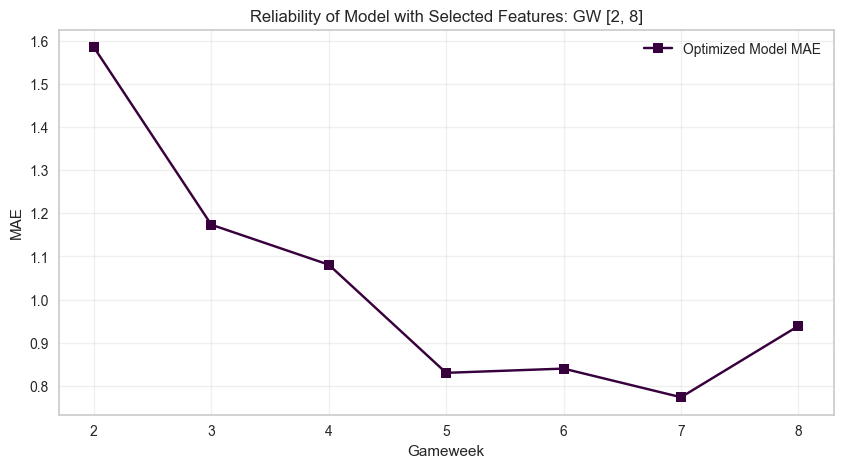

In [28]:
import matplotlib.pyplot as plt
# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [2, 8]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## GW 9+


In [29]:
hist_data = player_data[
    (player_data['round'] > 3)  &
    (player_data['minutes'] > 15)
    ]

data_identifiers_9 = hist_data[identifiers]
CATEGORICAL_COLS = ['was_home']
TEAM_COLS = ['team', 'opponent_team']
# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder_team = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(hist_data[CATEGORICAL_COLS])

encoded_team_array = encoder_team.fit(hist_data[TEAM_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_team_cols = encoder_team.get_feature_names_out(TEAM_COLS)

encoded_df = pd.DataFrame(
    encoder.transform(hist_data[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=hist_data.index
)

encoded_team_df = pd.DataFrame(
    encoder_team.transform(hist_data[TEAM_COLS]),
    columns=encoded_team_cols,
    index=hist_data.index
)


cols_ = [*cols, *encoded_cols]
data = pd.concat([hist_data[cols], encoded_df], axis=1)#.drop(columns=CATEGORICAL_COLS)
data

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,draw_prob,lose_prob,percentage_net_transfers,...,goals_prevented_3_ewm,goals_prevented_5_ewm,sweeper_actions_1_ewm,sweeper_actions_3_ewm,sweeper_actions_5_ewm,tackles_won_percent_1_ewm,tackles_won_percent_3_ewm,tackles_won_percent_5_ewm,was_home_False,was_home_True
43,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,0.106,0.056,-0.000263,...,0.0,0.0,0.0,0.0,0.0,0.0,15.625000,24.279835,0.0,1.0
46,68.0,98901.0,2012.0,6245.0,4.0,5.0,0.490,0.255,0.255,-0.000279,...,0.0,0.0,0.0,0.0,0.0,0.0,1.953125,7.194025,1.0,0.0
48,68.0,98145.0,1879.0,3456.0,4.0,5.0,0.693,0.201,0.106,0.000932,...,0.0,0.0,0.0,0.0,0.0,0.0,0.488281,3.197345,0.0,1.0
49,68.0,98296.0,1427.0,2426.0,2.0,5.0,0.654,0.211,0.135,0.000848,...,0.0,0.0,0.0,0.0,0.0,100.0,50.244141,35.464896,1.0,0.0
51,68.0,97896.0,1265.0,2615.0,3.0,5.0,0.592,0.219,0.189,-0.000706,...,0.0,0.0,0.0,0.0,0.0,0.0,12.561035,15.762176,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26858,45.0,231.0,92.0,18.0,2.0,1.0,0.411,0.263,0.326,0.000010,...,0.0,0.0,0.0,0.0,0.0,0.0,25.000000,22.222222,0.0,1.0
26859,45.0,330.0,131.0,43.0,3.0,1.0,0.111,0.180,0.709,0.000011,...,0.0,0.0,0.0,0.0,0.0,0.0,12.500000,14.814815,1.0,0.0
26897,45.0,1567.0,164.0,243.0,1.0,1.0,0.328,0.262,0.410,-0.000009,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.0,0.0
26899,44.0,3175.0,1260.0,325.0,3.0,1.0,0.126,0.199,0.675,0.000133,...,0.0,0.0,0.0,0.0,0.0,0.0,25.000000,22.222222,1.0,0.0


### Drop Near-Zero Variance


In [30]:
# Drop features with > 99% constant values
selector = VarianceThreshold(threshold=0.01)
data_reduced = pd.DataFrame(
    selector.fit_transform(data),
    columns=data.columns[selector.get_support()]
)

data_reduced

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,lose_prob,xP,selected_by_percent,...,goals_prevented_1_ewm,goals_prevented_3_ewm,sweeper_actions_1_ewm,sweeper_actions_3_ewm,sweeper_actions_5_ewm,tackles_won_percent_1_ewm,tackles_won_percent_3_ewm,tackles_won_percent_5_ewm,was_home_False,was_home_True
0,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,0.056,2.3,0.010283,...,0.0,0.0,0.0,0.0,0.0,0.0,15.625000,24.279835,0.0,1.0
1,68.0,98901.0,2012.0,6245.0,4.0,5.0,0.490,0.255,1.7,0.010085,...,0.0,0.0,0.0,0.0,0.0,0.0,1.953125,7.194025,1.0,0.0
2,68.0,98145.0,1879.0,3456.0,4.0,5.0,0.693,0.106,2.0,0.011096,...,0.0,0.0,0.0,0.0,0.0,0.0,0.488281,3.197345,0.0,1.0
3,68.0,98296.0,1427.0,2426.0,2.0,5.0,0.654,0.135,2.0,0.011943,...,0.0,0.0,0.0,0.0,0.0,100.0,50.244141,35.464896,1.0,0.0
4,68.0,97896.0,1265.0,2615.0,3.0,5.0,0.592,0.189,1.8,0.012076,...,0.0,0.0,0.0,0.0,0.0,0.0,12.561035,15.762176,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9078,45.0,231.0,92.0,18.0,2.0,1.0,0.411,0.326,1.0,0.000024,...,0.0,0.0,0.0,0.0,0.0,0.0,25.000000,22.222222,0.0,1.0
9079,45.0,330.0,131.0,43.0,3.0,1.0,0.111,0.709,0.5,0.000034,...,0.0,0.0,0.0,0.0,0.0,0.0,12.500000,14.814815,1.0,0.0
9080,45.0,1567.0,164.0,243.0,1.0,1.0,0.328,0.410,0.5,0.000152,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.0,0.0
9081,44.0,3175.0,1260.0,325.0,3.0,1.0,0.126,0.675,0.0,0.000324,...,0.0,0.0,0.0,0.0,0.0,0.0,25.000000,22.222222,1.0,0.0


### Drop High Multicollinearity


In [31]:
# Compute pairwise absolute correlation matrix
corr_matrix = data_reduced.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
df_filtered = data_reduced.drop(columns=to_drop)
df_filtered = df_filtered.fillna(0)
df_filtered

,value,selected,transfers_in,transfers_out,difficulty,opponent_difficulty,win_prob,xP,ownership_change,points_rolling_1,...,goals_prevented_rolling_1,goals_prevented_rolling_3,sweeper_actions_rolling_1,sweeper_actions_rolling_3,tackles_won_percent_rolling_1,tackles_won_percent_rolling_3,tackles_won_percent_rolling_5,clean_sheets_3_ewm,goals_prevented_3_ewm,was_home_False
0,68.0,97477.0,6898.0,8719.0,1.0,5.0,0.838,2.3,1858.0,1.0,...,0.0,0.0,0.0,0.0,0.0,16.666667,10.0,0.000,0.0,0.0
1,68.0,98901.0,2012.0,6245.0,4.0,5.0,0.490,1.7,-2295.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,10.0,0.000,0.0,1.0
2,68.0,98145.0,1879.0,3456.0,4.0,5.0,0.693,2.0,573.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,0.0
3,68.0,98296.0,1427.0,2426.0,2.0,5.0,0.654,2.0,151.0,1.0,...,0.0,0.0,0.0,0.0,100.0,33.333333,20.0,0.500,0.0,1.0
4,68.0,97896.0,1265.0,2615.0,3.0,5.0,0.592,1.8,-348.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.333333,20.0,0.125,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9078,45.0,231.0,92.0,18.0,2.0,1.0,0.411,1.0,89.0,1.0,...,0.0,0.0,0.0,0.0,0.0,33.333333,20.0,0.000,0.0,0.0
9079,45.0,330.0,131.0,43.0,3.0,1.0,0.111,0.5,99.0,1.0,...,0.0,0.0,0.0,0.0,0.0,33.333333,20.0,0.000,0.0,1.0
9080,45.0,1567.0,164.0,243.0,1.0,1.0,0.328,0.5,-56.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000,0.0,1.0
9081,44.0,3175.0,1260.0,325.0,3.0,1.0,0.126,0.0,1230.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.333333,20.0,0.000,0.0,1.0


### Statistical Filtering


In [32]:
y_train = df_filtered['xP']
X_train = df_filtered.drop(['xP'], axis=1)
# Keep top N features based on mutual information
k_best = SelectKBest(score_func=mutual_info_regression, k=30)
X_selected = k_best.fit_transform(X_train, y_train)

# Get selected column names
selected_cols = X_train.columns[k_best.get_support()]

selected_data = df_filtered[selected_cols]

data_9 = pd.concat([data_identifiers_9.reset_index(drop=True), y_train.reset_index(drop=True), selected_data.reset_index(drop=True), encoded_team_df.reset_index(drop=True)], axis=1)
data_9

,element,name,position,round,fixture,team,xP,value,selected,transfers_in,...,opponent_team_Leicester,opponent_team_Liverpool,opponent_team_Man City,opponent_team_Man Utd,opponent_team_Newcastle,opponent_team_Nott'm Forest,opponent_team_Southampton,opponent_team_Spurs,opponent_team_West Ham,opponent_team_Wolves
0,2,Gabriel Fernando de Jesus,Forward,7,61.0,Arsenal,2.3,68.0,97477.0,6898.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,Gabriel Fernando de Jesus,Forward,10,96.0,Arsenal,1.7,68.0,98901.0,2012.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,Gabriel Fernando de Jesus,Forward,12,111.0,Arsenal,2.0,68.0,98145.0,1879.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2,Gabriel Fernando de Jesus,Forward,13,129.0,Arsenal,2.0,68.0,98296.0,1427.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,Gabriel Fernando de Jesus,Forward,15,145.0,Arsenal,1.8,68.0,97896.0,1265.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9078,792,Jeremy Monga,Midfielder,37,368.0,Leicester,1.0,45.0,231.0,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9079,792,Jeremy Monga,Midfielder,38,371.0,Leicester,0.5,45.0,330.0,131.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9080,798,Jay Robinson,Forward,35,348.0,Southampton,0.5,45.0,1567.0,164.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9081,798,Jay Robinson,Forward,37,367.0,Southampton,0.0,44.0,3175.0,1260.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Predictor


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1858, 73)"
4,Transformed data shape,"(1858, 72)"
5,Transformed train set shape,"(1486, 72)"
6,Transformed test set shape,"(372, 72)"
7,Numeric features,71
8,Categorical features,1
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.7202,1.0022,0.9984,0.7439,0.2752,0.4299,0.0350
ridge,Ridge Regression,0.7205,1.0064,1.0006,0.7427,0.2757,0.4238,0.0330
lr,Linear Regression,0.7230,1.0106,1.0027,0.7416,0.2763,0.4245,0.4590
gbr,Gradient Boosting Regressor,0.7340,1.0481,1.0211,0.7311,0.2800,0.4542,0.1670
et,Extra Trees Regressor,0.7501,1.1237,1.0574,0.7126,0.2871,0.4685,0.3160
lightgbm,Light Gradient Boosting Machine,0.7656,1.1442,1.0676,0.7060,0.2899,0.4647,64.4980
rf,Random Forest Regressor,0.7668,1.1326,1.0615,0.7097,0.2901,0.4836,0.4730
en,Elastic Net,0.9415,1.5645,1.2469,0.6019,0.3452,0.6947,0.0550
ada,AdaBoost Regressor,0.9783,1.4780,1.2129,0.6195,0.3527,0.8047,0.1090
llar,Lasso Least Angle Regression,1.0097,1.7753,1.3283,0.5487,0.3652,0.7576,0.0380


BayesianRidge()


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

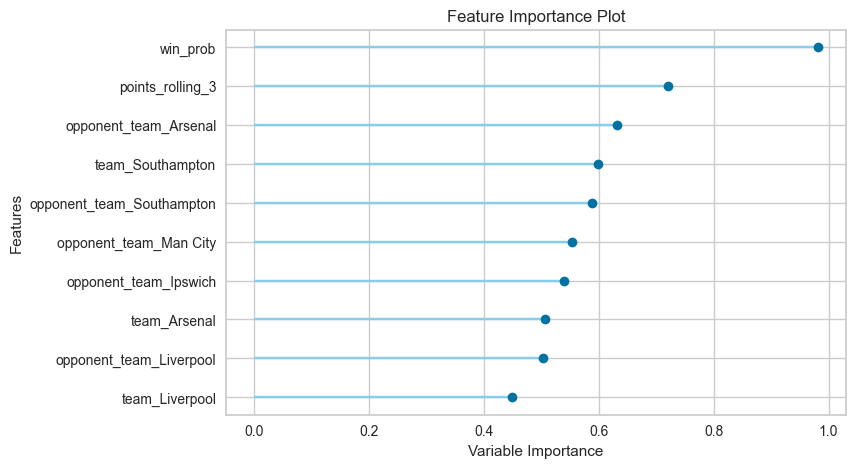

In [ ]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data_9, 11)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True
                )

best_model_11 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_11)

evaluate_model(best_model_11)

plot_model(best_model_11, plot='feature')        # Feature importance


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2120, 73)"
4,Transformed data shape,"(2120, 73)"
5,Transformed train set shape,"(1696, 73)"
6,Transformed test set shape,"(424, 73)"
7,Numeric features,71
8,Categorical features,1
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.7283,1.0040,1.0006,0.7322,0.2781,0.4495,0.0330
ridge,Ridge Regression,0.7303,1.0090,1.0031,0.7308,0.2781,0.4454,0.0330
lr,Linear Regression,0.7319,1.0118,1.0045,0.7300,0.2785,0.4452,0.4920
gbr,Gradient Boosting Regressor,0.7374,1.0279,1.0120,0.7257,0.2771,0.4618,0.1760
lightgbm,Light Gradient Boosting Machine,0.7403,1.0552,1.0258,0.7191,0.2807,0.4607,55.4800
et,Extra Trees Regressor,0.7546,1.1135,1.0525,0.7050,0.2865,0.4919,0.3130
rf,Random Forest Regressor,0.7629,1.1078,1.0503,0.7055,0.2880,0.5024,0.5510
en,Elastic Net,0.9458,1.5553,1.2448,0.5877,0.3501,0.7105,0.0590
ada,AdaBoost Regressor,0.9775,1.4608,1.2079,0.6115,0.3599,0.8190,0.1060
llar,Lasso Least Angle Regression,1.0117,1.7448,1.3186,0.5372,0.3699,0.7708,0.0330


BayesianRidge()


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

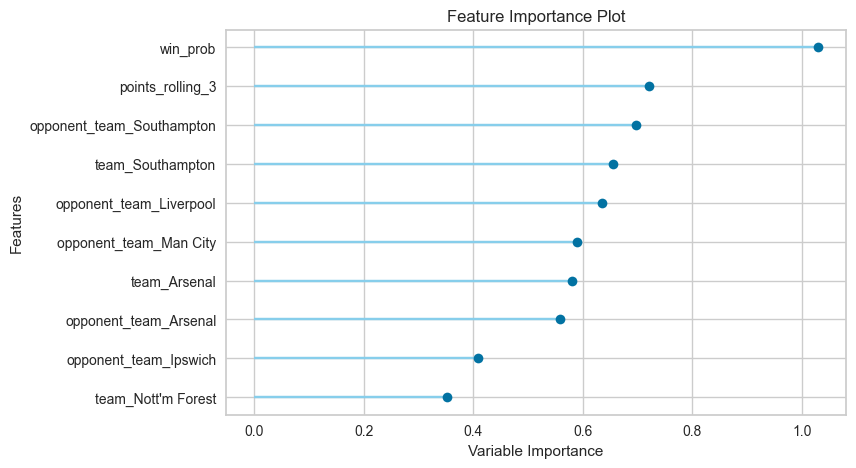

In [35]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data_9, 12)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True
                )

best_model_12 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_12)

evaluate_model(best_model_12)

plot_model(best_model_12, plot='feature')        # Feature importance


In [34]:
feats_9 = selected_cols.tolist()
selected_features_9 = {}
for round in range(9,39):
    selected_features_9[round] = get_gw_best_features(data_9, round, feats_9)


Step 1: Ranking Features for GW 9 using Recursive Feature Elimination...
(1336, 30)

Step 2: Finding Optimal Feature Cut-off. of the 30 features..
Testing top 1 features: Average MAE = 1.3628
Testing top 2 features: Average MAE = 1.0844
Testing top 3 features: Average MAE = 0.9651
Testing top 4 features: Average MAE = 0.9783
Testing top 5 features: Average MAE = 0.9436
Testing top 6 features: Average MAE = 0.9188
Testing top 7 features: Average MAE = 0.9099
Testing top 8 features: Average MAE = 0.7273
Testing top 9 features: Average MAE = 0.7114
Testing top 10 features: Average MAE = 0.7152
Testing top 11 features: Average MAE = 0.7203
Testing top 12 features: Average MAE = 0.7164
Testing top 13 features: Average MAE = 0.7340
Testing top 14 features: Average MAE = 0.7387
Testing top 15 features: Average MAE = 0.7290
Testing top 16 features: Average MAE = 0.7368
Testing top 17 features: Average MAE = 0.7418
Testing top 18 features: Average MAE = 0.7354


KeyboardInterrupt: 

In [ ]:
selections_9 = pd.DataFrame(selected_features_9).T
selections_9.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves', 'xP_predictions']
selections_9

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves,xP_predictions
9,"[win_prob, ict_index_rolling_3, transfers_in, ...",27,0.719563,0.05,15.0,"[2.4439616225868885, 4.2817496479975246, 1.469..."
10,"[win_prob, ict_index_rolling_3, influence_roll...",29,0.87624,0.05,15.0,"[1.2239494230521133, 2.084734794638546, 3.6366..."
11,"[win_prob, transfers_in, xP_rolling_3, expecte...",15,0.926631,0.05,15.0,"[2.007133060857861, 2.1065322054435747, 1.4983..."
12,"[win_prob, transfers_in, influence_rolling_5, ...",24,1.022135,0.1,15.0,"[2.251582112283957, 3.1668228788310846, 3.1691..."
13,"[win_prob, expected_goals_conceded_rolling_1, ...",17,0.643189,0.05,15.0,"[2.245386923502114, 4.355355295449687, 2.29668..."
14,"[win_prob, expected_goals_conceded_rolling_1, ...",12,0.697195,0.05,15.0,"[3.725931089036631, 3.93857584833435, 1.968376..."
15,"[win_prob, expected_goals_conceded_rolling_1, ...",24,0.668666,0.05,15.0,"[1.49962084663248, 3.4871774968406486, 6.08175..."
16,"[win_prob, transfers_in, expected_goals_conced...",20,0.806371,0.05,63.0,"[2.342495350827819, 3.1500158885414105, 4.6133..."
17,"[win_prob, expected_goals_conceded_rolling_3, ...",9,0.581726,0.05,15.0,"[1.9015763503398442, 5.1181624899414855, 3.261..."
18,"[win_prob, ownership_change, clean_sheets_3_ew...",6,0.577561,0.05,15.0,"[5.333386618412885, 6.134356479880094, 5.14821..."


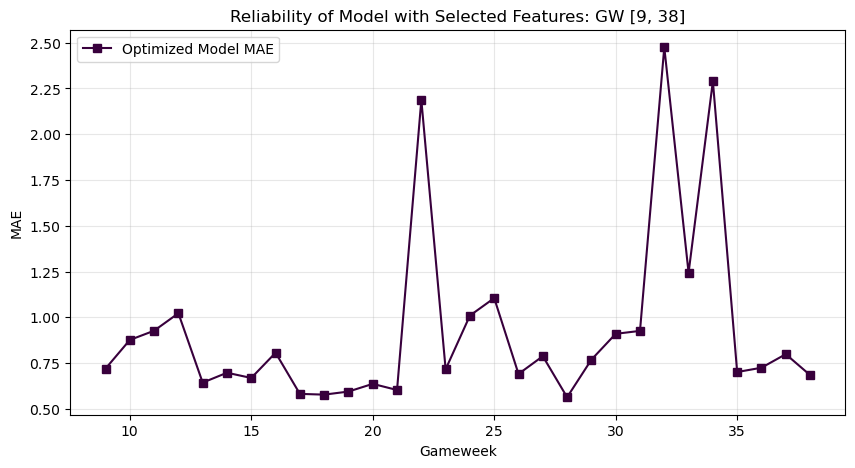

In [ ]:
import matplotlib.pyplot as plt
# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections_9.index, selections_9['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [9, 38]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
